In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"navadeepreddyduttala","key":"e510f19b448ca6f5610e5b4199f6e400"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d xiaopengzhang12/lung-cancer-mri-images

Dataset URL: https://www.kaggle.com/datasets/xiaopengzhang12/lung-cancer-mri-images
License(s): unknown
 96% 500M/522M [00:01<00:00, 310MB/s]
100% 522M/522M [00:01<00:00, 351MB/s]


In [ ]:
!unzip lung-cancer-mri-images.zip

Archive:  lung-cancer-mri-images.zip
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (10).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (100).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1000).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1001).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1002).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1003).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1004).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1005).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1006).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1007).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1008).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1009).png  
  inflating: lung_cancer_MRI_data

In [ ]:
import zipfile

with zipfile.ZipFile("lung-cancer-mri-images.zip", 'r') as zip_ref:
    zip_ref.extractall("lung_dataset")

In [ ]:
import os
import shutil
import random

# Define base directories
base_dataset_root = "lung_dataset/lung_cancer_MRI_dataset"  # This is where 'train' and 'validate' are
train_data_output_dir = "lung_data_split/train"
val_data_output_dir = "lung_data_split/val"

# Create output directories
os.makedirs(train_data_output_dir, exist_ok=True)
os.makedirs(val_data_output_dir, exist_ok=True)

# Define the dataset subsets (e.g., 'train', 'validate' from the original dataset)
dataset_subsets = [d for d in os.listdir(base_dataset_root) if os.path.isdir(os.path.join(base_dataset_root, d))]

# Get the class names (e.g., 'cancer', 'normal')
class_names = []
# Assuming classes are consistent across subsets, pick one to get class names
if dataset_subsets:
    first_subset_path = os.path.join(base_dataset_root, dataset_subsets[0])
    class_names = [d for d in os.listdir(first_subset_path) if os.path.isdir(os.path.join(first_subset_path, d))]

# For each class, gather all images, then split and copy
for class_name in class_names:
    all_images_for_class = []

    # Collect images from all original dataset subsets (e.g., 'train', 'validate') for the current class
    for subset in dataset_subsets:
        current_class_path = os.path.join(base_dataset_root, subset, class_name)
        if os.path.isdir(current_class_path):
            images = [os.path.join(current_class_path, img) for img in os.listdir(current_class_path) if os.path.isfile(os.path.join(current_class_path, img))]
            all_images_for_class.extend(images)

    random.shuffle(all_images_for_class)

    split_point = int(0.8 * len(all_images_for_class))
    train_imgs = all_images_for_class[:split_point]
    val_imgs = all_images_for_class[split_point:]

    # Create class directories in the new train/val output folders
    os.makedirs(os.path.join(train_data_output_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_data_output_dir, class_name), exist_ok=True)

    # Copy images to new train directory
    for img_path in train_imgs:
        dest_path = os.path.join(train_data_output_dir, class_name, os.path.basename(img_path))
        shutil.copy(img_path, dest_path)

    # Copy images to new validation directory
    for img_path in val_imgs:
        dest_path = os.path.join(val_data_output_dir, class_name, os.path.basename(img_path))
        shutil.copy(img_path, dest_path)

print("Dataset split into new train and validation sets successfully.")

Dataset split into new train and validation sets successfully.


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder("lung_data_split/train", transform=transform)
val_dataset = datasets.ImageFolder("lung_data_split/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes: ", class_names)

Classes:  ['cancer', 'no_cancer']


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

num_features = model.heads.head.in_features
model.heads.head = nn.Linear(num_features, 2)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation loss
    model.eval()
    running_val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")

Epoch [1/10] Train Loss: 0.5007 Val Loss: 0.4167
Epoch [2/10] Train Loss: 0.3672 Val Loss: 0.3618
Epoch [3/10] Train Loss: 0.3439 Val Loss: 0.3656
Epoch [4/10] Train Loss: 0.3569 Val Loss: 0.3553
Epoch [5/10] Train Loss: 0.3248 Val Loss: 0.3984
Epoch [6/10] Train Loss: 0.2952 Val Loss: 0.3685
Epoch [7/10] Train Loss: 0.2864 Val Loss: 0.4099
Epoch [8/10] Train Loss: 0.2764 Val Loss: 0.3635
Epoch [9/10] Train Loss: 0.2453 Val Loss: 0.4345
Epoch [10/10] Train Loss: 0.2066 Val Loss: 0.4527


In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Total predictions:", len(all_preds))
print("Total labels:", len(all_labels))

Total predictions: 719
Total labels: 719


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nFull Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Accuracy: 0.8456189151599444
Precision: 0.8550270695515165
Recall: 0.8456189151599444
F1 Score: 0.8444822749595874

Full Classification Report:

              precision    recall  f1-score   support

      cancer       0.91      0.76      0.83       357
   no_cancer       0.80      0.93      0.86       362

    accuracy                           0.85       719
   macro avg       0.86      0.85      0.84       719
weighted avg       0.86      0.85      0.84       719



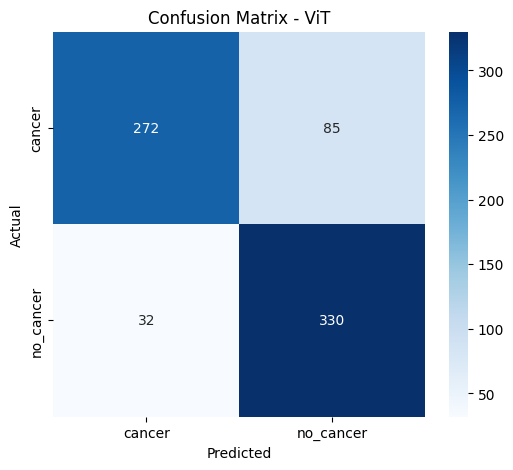

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ViT")
plt.show()

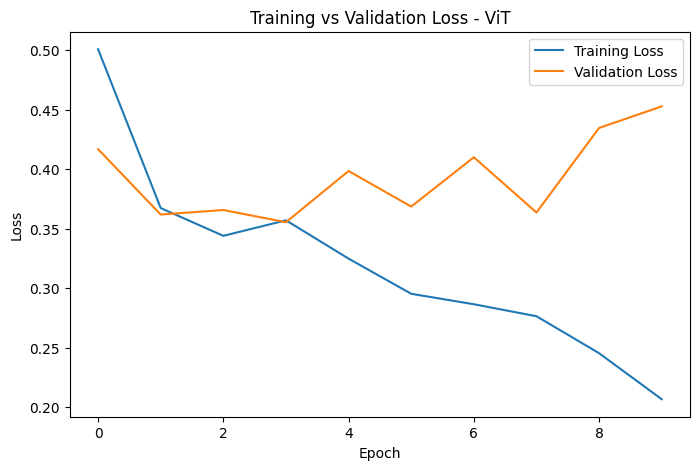

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - ViT")
plt.legend()
plt.show()